In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

In [3]:
data=pd.read_csv("C:/Users/HP/Desktop/Crypto_project/business project/data/Snitch_Fashion_Sales_Uncleaned.csv")

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2500 non-null   int64  
 1   Customer_Name     2500 non-null   str    
 2   Product_Category  2500 non-null   str    
 3   Product_Name      2500 non-null   str    
 4   Units_Sold        1194 non-null   float64
 5   Unit_Price        1290 non-null   float64
 6   Discount_%        849 non-null    float64
 7   Sales_Amount      2500 non-null   float64
 8   Order_Date        1894 non-null   str    
 9   City              2500 non-null   str    
 10  Segment           1679 non-null   str    
 11  Profit            2500 non-null   float64
dtypes: float64(5), int64(1), str(6)
memory usage: 234.5 KB


In [5]:
data.describe()

,Order_ID,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Profit
count,2500.000000,1194.000000,1290.000000,849.000000,2500.000000,2500.000000
mean,2193.060000,1.940536,2691.715527,0.646466,126.756252,981.569032
std,748.063846,2.625680,1320.448967,0.380331,1464.944525,1159.159244
min,1000.000000,-2.000000,400.210000,0.000000,-7518.330000,-992.610000
25%,1543.750000,0.000000,1526.195000,0.300000,0.000000,-19.670000
50%,2182.500000,2.000000,2685.985000,0.650000,0.000000,947.885000
75%,2842.250000,4.000000,3824.347500,0.980000,0.000000,1993.515000
max,3499.000000,6.000000,4998.910000,1.300000,29180.680000,2997.110000


In [6]:
data.shape

(2500, 12)

In [7]:
data.isna().sum()

Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold          1306
Unit_Price          1210
Discount_%          1651
Sales_Amount           0
Order_Date           606
City                   0
Segment              821
Profit                 0
dtype: int64

“I observed high missingness in several variables, so instead of naive imputation, I used business-informed strategies like treating missing discounts as zero and applying category-level imputation for price and quantity. For time analysis, I used only valid date records to avoid introducing artificial patterns.”

In [8]:
data.head()

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,NaN,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,NaN,NaN,0.00,2025-07-15,Ahmedabad,NaN,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,NaN,0.00,02-01-2025,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,NaN,0.00,18-06-2025,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaN,hyderbad,NaN,63.66


In [9]:
data.shape

(2500, 12)

In [10]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], errors='coerce')

“Since dropping missing dates would result in significant data loss, I retained the full dataset for overall analysis and used a subset with valid dates specifically for time-based insights.”

In [11]:
data['Discount_%'].isna().sum()

np.int64(1651)

## Handling Missing Values in Discount %

The `Discount_%` column had a high proportion of missing values (~66%).

### Approach:
- Missing values were treated as **no discount applied**
- This assumption aligns with business logic where absence of discount data often implies no discount

### Action:
- Missing values were replaced with `0`

### Justification:
This ensures:
- No artificial inflation of discount values
- Logical consistency with pricing behavior

In [12]:
data['Discount_%'] = data['Discount_%'].fillna(0)

In [13]:
data['Discount_%'].isna().sum()

np.int64(0)

In [14]:
data['Units_Sold'].describe()

count    1194.000000
mean        1.940536
std         2.625680
min        -2.000000
25%         0.000000
50%         2.000000
75%         4.000000
max         6.000000
Name: Units_Sold, dtype: float64

In [15]:
data.groupby('Product_Category')['Units_Sold'].median()

Product_Category
Accessories    2.0
Dresses        2.0
Jackets        2.0
Jeans          1.5
Shoes          2.0
T-Shirts       2.0
Name: Units_Sold, dtype: float64

## Cleaning and Imputing Units Sold

The `Units_Sold` column had:
- ~52% missing values
- Invalid entries (negative values)

### Step 1: Handle Invalid Values
- Negative values were identified as invalid
- These were converted to missing values (NaN)

### Step 2: Imputation Strategy
- Since demand varies by product type, **category-level median imputation** was used

### Justification:
- Preserves product-specific demand patterns
- Avoids bias introduced by global averages
- More realistic representation of sales behavior

In [16]:
data[data['Units_Sold']<0]

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
24,1024,Thomas Long,Jackets,Puffer Coat,-2.0,NaN,1.19,0.00,NaT,Delhi,B2B,491.10
28,1028,Felicia Orozco,T-Shirts,Classic Tee,-2.0,NaN,0.00,0.00,NaT,hyderbad,B2B,2060.03
35,1035,Joshua Thomas,Jackets,Bomber Jacket,-1.0,NaN,0.94,0.00,NaT,Ahmedabad,B2C,-199.18
36,1036,Connie Cunningham,T-Shirts,Graphic Tee,-2.0,2721.83,0.00,0.00,2024-04-06,Ahmedabad,B2B,1213.95
46,1046,Charlotte Cook,Jeans,Slim Fit Jeans,-1.0,2441.92,0.92,-195.35,NaT,Delhi,NaN,1004.91
...,...,...,...,...,...,...,...,...,...,...,...,...
2439,3439,Jeremiah Reese,Shoes,Slip-ons,-2.0,400.21,0.00,0.00,NaT,Bangalore,B2C,914.27
2451,3451,Roger Blake,T-Shirts,Graphic Tee,-2.0,2339.36,0.35,-3041.17,NaT,Bangalore,B2B,-5.05
2465,3465,Joshua Hill,Jeans,Boyfriend Jeans,-1.0,NaN,0.70,0.00,2024-09-07,Hyd,B2B,-288.96
2482,3482,Brenda Gonzales,Accessories,Watches,-2.0,1169.89,0.00,0.00,NaT,Pune,B2C,161.95


In [17]:
data.loc[data['Units_Sold']<0,'Units_Sold']=np.nan

In [18]:
data['Units_Sold'].describe()

count    911.000000
mean       3.012075
std        2.027521
min        0.000000
25%        1.000000
50%        3.000000
75%        5.000000
max        6.000000
Name: Units_Sold, dtype: float64

In [19]:
data['Units_Sold']=data['Units_Sold'].fillna(data.groupby('Product_Category')['Units_Sold'].transform('median'))

In [20]:
data['Units_Sold'].isna().sum()

np.int64(0)

In [21]:
data['Unit_Price'].describe()

count    1290.000000
mean     2691.715527
std      1320.448967
min       400.210000
25%      1526.195000
50%      2685.985000
75%      3824.347500
max      4998.910000
Name: Unit_Price, dtype: float64

In [23]:
data.groupby('Product_Category')['Unit_Price'].median()

Product_Category
Accessories    2571.890
Dresses        2899.915
Jackets        2551.670
Jeans          2705.090
Shoes          2558.430
T-Shirts       2670.635
Name: Unit_Price, dtype: float64

## Handling Missing Values in Unit Price

The `Unit_Price` column had ~48% missing values.

### Analysis:
- Prices vary across product categories (e.g., dresses vs accessories)

### Approach:
- Used **Product_Category-wise median imputation**

### Justification:
- Price is dependent on product type
- Global imputation would distort pricing structure
- Maintains realistic price distribution across categories

In [24]:
data['Unit_Price']=data['Unit_Price'].fillna(data.groupby('Product_Category')['Unit_Price'].transform('median'))

In [25]:
data['Unit_Price'].isna().sum()

np.int64(0)

In [26]:
data['Segment'].unique()

<StringArray>
['B2C', nan, 'B2B']
Length: 3, dtype: str

In [27]:
data['Segment'] = data['Segment'].fillna('Unknown')

In [28]:
data['Segment'].isna().sum()

np.int64(0)

## Handling Missing Values in Segment

The `Segment` column had ~33% missing values.

### Approach:
- Missing values were replaced with `"Unknown"`

### Justification:
- Avoids incorrect assumptions about customer type
- Retains all data points
- Treats missing information as a meaningful category

In [29]:
data.isna().sum()

Order_ID               0
Customer_Name          0
Product_Category       0
Product_Name           0
Units_Sold             0
Unit_Price             0
Discount_%             0
Sales_Amount           0
Order_Date          1872
City                   0
Segment                0
Profit                 0
dtype: int64

## Final Data Cleaning Summary

The dataset was cleaned using a combination of:
- Data type corrections
- Handling invalid values
- Logical imputation strategies

### Key Steps:
- Replaced missing discounts with 0
- Corrected invalid units sold values
- Applied category-based imputation for units and price
- Treated missing categorical values as "Unknown"
- Preserved missing dates for selective analysis

### Outcome:
- Clean and consistent dataset
- Ready for exploratory data analysis (EDA)
- Maintains both statistical and business validity

In [30]:
data['Sales_Amount'].sum()

np.float64(316890.63)

The total revenue generated is around ₹3.16 lakh, which provides a baseline for evaluating product performance, pricing strategies, and customer behavior.”

In [31]:
data.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)

Product_Category
Dresses        91044.93
Jackets        54656.69
Jeans          48072.38
Accessories    46838.93
Shoes          41782.84
T-Shirts       34494.86
Name: Sales_Amount, dtype: float64

In [32]:
category_sales = data.groupby('Product_Category')['Sales_Amount'].sum().sort_values(ascending=False)
category_sales

Product_Category
Dresses        91044.93
Jackets        54656.69
Jeans          48072.38
Accessories    46838.93
Shoes          41782.84
T-Shirts       34494.86
Name: Sales_Amount, dtype: float64

<Axes: xlabel='Product_Category'>

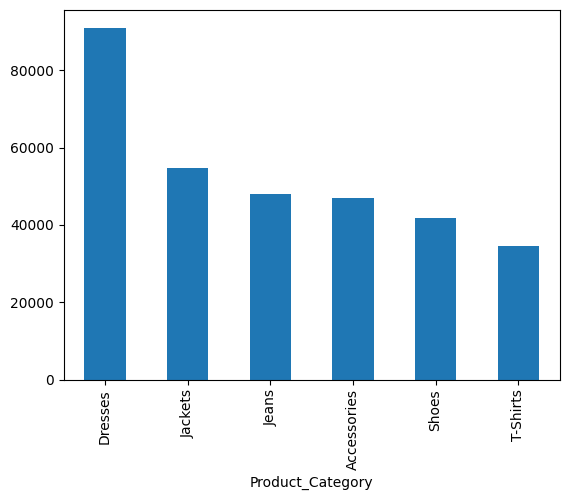

In [33]:
category_sales.plot(kind='bar')

##  Revenue Contribution by Product Category

The bar chart above shows the total sales generated by each product category.

###  Key Insights:

- **Dresses** are the top-performing category, contributing the highest revenue.
- **Jackets** come second, indicating strong demand in outerwear.
- **Jeans, Accessories, and Shoes** show moderate and relatively similar performance.
- **T-Shirts** generate the lowest revenue among all categories.

###  Interpretation:

- Revenue is **not evenly distributed** across categories.
- A few categories (especially Dresses) are driving a **large portion of total sales**.

###  Business Implications:

- Focus marketing efforts on **high-performing categories like Dresses and Jackets**
- Investigate why **T-Shirts are underperforming**
- Optimize inventory by prioritizing **high-revenue categories**
- Consider bundling or promotional strategies for lower-performing products
###  Conclusion:

The business appears to rely heavily on a few key product categories, highlighting opportunities for both:
- Scaling top performers
- Improving weaker segments

In [34]:
top_products = data.groupby('Product_Name')['Sales_Amount'].sum().sort_values(ascending=False).head(10)
top_products

Product_Name
Casual Midi        43656.41
Boyfriend Jeans    33019.26
Leather Jacket     31739.29
Belts              27495.10
Wrap Dress         25571.30
Bodycon            20886.66
Sneakers           17205.87
Crop Top           13547.46
Classic Tee        11424.81
Bomber Jacket      11291.05
Name: Sales_Amount, dtype: float64

<Axes: xlabel='Product_Name'>

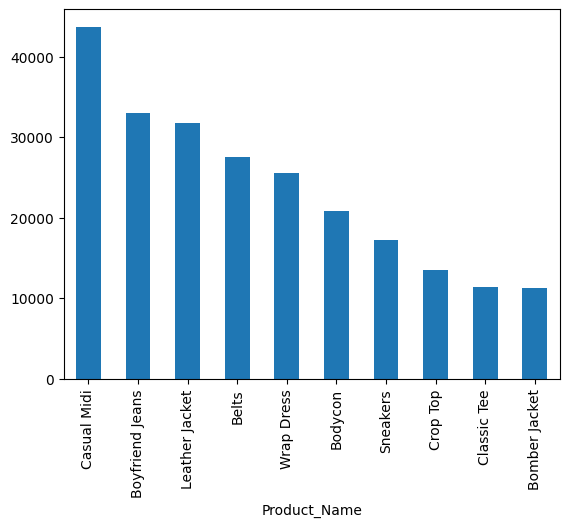

In [35]:
top_products.plot(kind='bar')

##  Top Performing Products by Revenue

The chart above highlights the top 10 revenue-generating products.

###  Key Insights:

- **Casual Midi** is the highest revenue-generating product, making it a key driver of sales.
- **Boyfriend Jeans** and **Leather Jacket** follow as strong performers.
- Products like **Belts** and **Wrap Dress** also contribute significantly to revenue.
- Lower in the top 10 are items like **Classic Tee** and **Bomber Jacket**, but they still contribute meaningfully.

### Interpretation:

- Revenue is concentrated among a **few high-performing products**
- A mix of categories (dresses, jeans, jackets, accessories) appears in the top 10, indicating **diverse demand**
- Certain products consistently outperform others, suggesting strong customer preference

### Business Implications:

- Ensure high availability of **top-selling products like Casual Midi and Boyfriend Jeans**
- Use these products in **featured promotions and advertisements**
- Analyze characteristics (price, style, category) of top performers to replicate success
- Consider bundling slower products with bestsellers

### Conclusion:

A small group of products drives a large portion of revenue, highlighting the importance of focusing on best-performing items for maximizing business growth.

In [36]:
low_products = data.groupby('Product_Name')['Sales_Amount'].sum().sort_values().head(10)
low_products

Product_Name
Denim Jacket          902.45
Maxi Dress            930.56
Graphic Tee          2310.07
Caps                 2372.85
Straight Cut         2667.61
Slip-ons             5471.87
Ripped Denim         5693.24
Slim Fit Jeans       6692.27
Watches              6796.38
Oversized T-shirt    7212.52
Name: Sales_Amount, dtype: float64

<Axes: xlabel='Product_Name'>

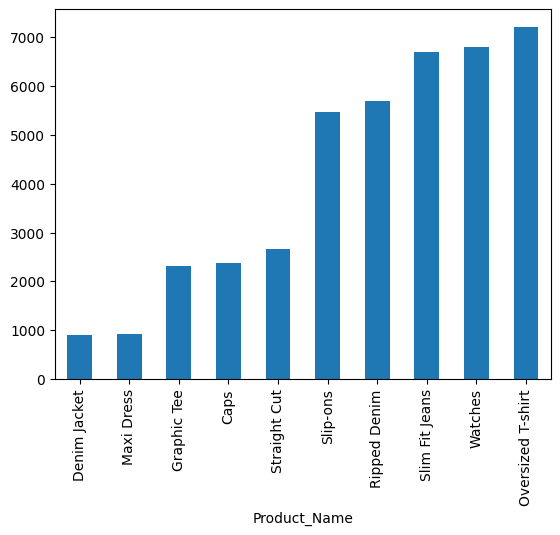

In [37]:
low_products.plot(kind='bar')

## Insights from Low Performing Products

- Some products contribute very little to overall revenue
- These may suffer from low demand, poor pricing, or lack of visibility
- Certain categories may consistently appear among low performers

### Business Implications:

- Consider discontinuing or redesigning consistently low-performing products
- Improve marketing or visibility for these items
- Re-evaluate pricing strategy
- Bundle these products with high-performing items to increase sales

### Conclusion:

Identifying low-performing products helps in optimizing inventory and improving overall profitability by focusing on what truly drives revenue.

In [38]:
category_profit = data.groupby('Product_Category')['Profit'].sum().sort_values(ascending=False)
category_profit

Product_Category
Dresses        451572.72
Accessories    421398.37
T-Shirts       403286.18
Jeans          396637.43
Shoes          393310.49
Jackets        387717.39
Name: Profit, dtype: float64

<Axes: xlabel='Product_Category'>

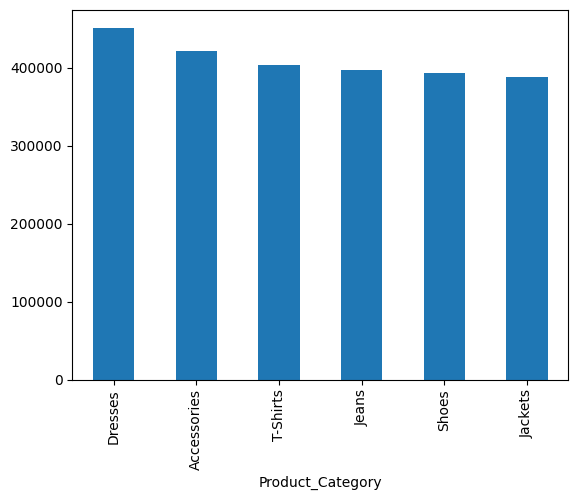

In [39]:
category_profit.plot(kind='bar')

## Profit Analysis by Product Category

The chart above shows the total profit generated by each product category.

### Key Insights:

- **Dresses** generate the highest profit, making them the most valuable category.
- **Accessories** and **T-Shirts** also contribute significantly to overall profit.
- **Jeans, Shoes, and Jackets** show slightly lower but comparable profit levels.
- Profit distribution is relatively balanced, with no extreme outliers.

###  Interpretation:

- Categories that perform well in revenue (like Dresses) also tend to perform well in profit
- However, differences between categories are not very large, indicating **consistent margins across products**
- This suggests a **stable pricing and cost structure**

### Business Implications:

- Focus on scaling **Dresses**, as they lead in both revenue and profit
- Maintain strong inventory for **Accessories and T-Shirts**, as they also contribute significantly
- Since profit margins are similar across categories, **volume growth can directly improve total profit**
- No category appears to be significantly underperforming in terms of profitability

### Conclusion:

The business shows a well-balanced profit distribution across categories, with Dresses leading as the most profitable segment. This indicates a stable and scalable business model.

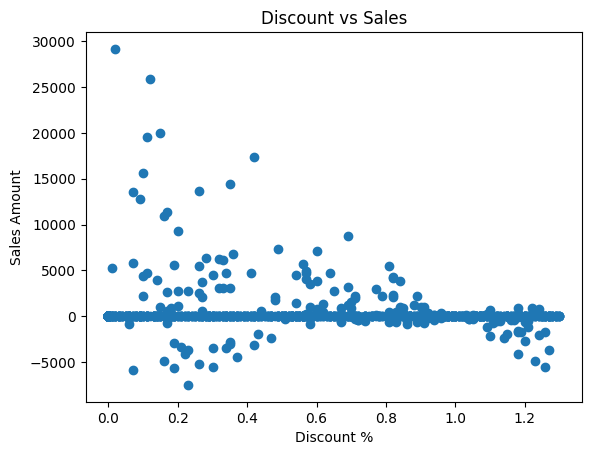

In [40]:
plt.scatter(data['Discount_%'], data['Sales_Amount'])
plt.xlabel('Discount %')
plt.ylabel('Sales Amount')
plt.title('Discount vs Sales')
plt.show()

In [41]:
data[['Discount_%', 'Sales_Amount']].corr()

,Discount_%,Sales_Amount
Discount_%,1.000000,-0.002318
Sales_Amount,-0.002318,1.000000


In [42]:
model_data = data.drop(columns=['Order_ID', 'Customer_Name', 'Order_Date'])
model_data = pd.get_dummies(model_data, drop_first=True)

In [48]:
X = model_data.drop(['Sales_Amount','Profit'], axis=1)
y = model_data['Profit']

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
37,City_bengaluru,240.788364
35,City_Mumbai,232.287017
36,City_Pune,194.377148
38,City_hyderbad,193.653135
33,City_Hyd,168.618552
31,City_Bangalore,160.703377
26,Product_Name_Sneakers,154.950418
19,Product_Name_Loafers,142.821752
20,Product_Name_Maxi Dress,116.531944
32,City_Delhi,94.047936


In [51]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

-0.029267818920905242

In [53]:
data.head()

,Order_ID,Customer_Name,Product_Category,Product_Name,Units_Sold,Unit_Price,Discount_%,Sales_Amount,Order_Date,City,Segment,Profit
0,1000,Brian Thompson,Jeans,Slim Fit Jeans,3.0,842.00,0.60,0.00,2025-02-27,Delhi,B2C,2137.45
1,1001,Shaun Ross,Jeans,Slim Fit Jeans,1.0,2705.09,0.00,0.00,2025-07-15,Ahmedabad,Unknown,1588.15
2,1002,Sarah Snyder,Jackets,Puffer Coat,1.0,637.82,0.00,0.00,NaT,Mumbai,B2B,-158.03
3,1003,Jay Briggs,Shoes,Loafers,2.0,2962.27,0.00,0.00,NaT,bengaluru,B2B,2296.50
4,1004,Maria Blake,Accessories,Belts,1.0,2881.07,0.27,2103.18,NaT,hyderbad,Unknown,63.66


In [54]:
data.to_csv('cleaned_business.csv',index=False)